In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats



# 1. Dataset

**`customer_booking.csv`**: reservas de vuelos realizadas por clientes de una aerolínea, con el detalle del viaje,
los adicionales solicitados y si la reserva se completó o no.

- **Tamaño:** 50.000 filas × 15 columnas

## 2. Planteo de hipótesis

- **H1:** a mayor antelación de la compra, mayor probabilidad de que la reserva **no** se complete.
- **H2:** a más adicionales solicitados (equipaje extra, asiento preferido, comidas), menor probabilidad de que la reserva no se complete.
- **H3:** la conversión depende del país desde donde se reserva.
- **H4:** ante exactamente la misma ruta, es más barato reservar por **Mobile** que por **Internet** (web).

En todo el trabajo, **conversión** = porcentaje de reservas completadas (`booking_complete = 1`).

## 3. Carga, análisis y limpieza de datos


# 3.1 Carga

In [2]:

df = pd.read_csv("customer_booking.csv", encoding="ISO-8859-1")
df.shape

(50000, 15)

# 3.2 Análisis

In [3]:

df.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete,booking_cost
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0,987.30
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0,406.91
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0,875.51
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0,508.69
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0,1097.63


In [4]:
df.tail()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete,booking_cost
49995,2,Internet,RoundTrip,27,6,9,Sat,PERPNH,Australia,1,0,1,5.62,0,1383.71
49996,1,Internet,RoundTrip,111,6,4,Sun,PERPNH,Australia,0,0,0,5.62,0,476.71
49997,1,Internet,RoundTrip,24,6,22,Sat,PERPNH,Australia,0,0,1,5.62,0,587.70
49998,1,Internet,RoundTrip,15,6,11,Mon,PERPNH,Australia,1,0,1,5.62,0,653.75
49999,1,Internet,RoundTrip,19,6,10,Thu,PERPNH,Australia,0,1,0,5.62,0,692.88


In [6]:
df.sample(10)

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete,booking_cost
28317,1,Internet,RoundTrip,21,3,2,Wed,JOGTPE,Taiwan,0,0,0,4.67,0,555.25
10269,2,Internet,RoundTrip,48,31,10,Tue,DMKSYD,Australia,1,0,0,8.58,0,2010.14
38010,1,Internet,RoundTrip,33,5,11,Mon,HGHHKT,China,0,0,0,5.07,0,463.82
2193,2,Mobile,RoundTrip,22,21,8,Sat,AKLTPE,Taiwan,1,0,0,4.67,0,1027.64
247,1,Internet,RoundTrip,6,21,21,Sun,AKLKUL,New Zealand,0,0,0,8.83,0,1018.82
43722,1,Internet,RoundTrip,12,6,1,Tue,COKMEL,Australia,1,0,1,8.83,0,939.71
32804,1,Internet,RoundTrip,25,4,6,Tue,ICNSIN,South Korea,0,0,0,6.62,0,669.74
13283,1,Internet,RoundTrip,112,28,4,Sat,HYDSYD,India,1,1,1,8.58,0,842.73
27650,2,Internet,RoundTrip,96,3,7,Sat,HKTKIX,Japan,1,1,1,7.00,0,1288.73
36186,1,Internet,RoundTrip,58,5,10,Mon,COKPER,Australia,0,1,1,5.62,0,439.43


In [7]:
df.info()

## No hay nulos.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  object 
 2   trip_type              50000 non-null  object 
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  object 
 7   route                  50000 non-null  object 
 8   booking_origin         50000 non-null  object 
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
 14  booking_cost           50000 non-null  float64
dtypes:

In [8]:
df.sales_channel.unique()


array(['Internet', 'Mobile'], dtype=object)

In [9]:
df.trip_type.unique()

array(['RoundTrip', 'CircleTrip', 'OneWay'], dtype=object)

In [10]:
df.flight_day.unique()

array(['Sat', 'Wed', 'Thu', 'Mon', 'Sun', 'Tue', 'Fri'], dtype=object)

In [11]:
df.booking_origin.unique()

array(['New Zealand', 'India', 'United Kingdom', 'China', 'South Korea',
       'Japan', 'Malaysia', 'Singapore', 'Switzerland', 'Germany',
       'Indonesia', 'Czech Republic', 'Vietnam', 'Thailand', 'Spain',
       'Romania', 'Ireland', 'Italy', 'Slovakia', 'United Arab Emirates',
       'Tonga', 'Rï¿½union', '(not set)', 'Saudi Arabia', 'Netherlands',
       'Qatar', 'Hong Kong', 'Philippines', 'Sri Lanka', 'France',
       'Croatia', 'United States', 'Laos', 'Hungary', 'Portugal',
       'Cyprus', 'Australia', 'Cambodia', 'Poland', 'Belgium', 'Oman',
       'Bangladesh', 'Kazakhstan', 'Brazil', 'Turkey', 'Kenya', 'Taiwan',
       'Brunei', 'Chile', 'Bulgaria', 'Ukraine', 'Denmark', 'Colombia',
       'Iran', 'Bahrain', 'Solomon Islands', 'Slovenia', 'Mauritius',
       'Nepal', 'Russia', 'Kuwait', 'Mexico', 'Sweden', 'Austria',
       'Lebanon', 'Jordan', 'Greece', 'Mongolia', 'Canada', 'Tanzania',
       'Peru', 'Timor-Leste', 'Argentina', 'New Caledonia', 'Macau',
       'Myanmar

In [12]:
df.booking_complete.unique()

## 0 No finalizado / 1 finalizado

array([0, 1])

In [13]:
df.describe()

# Valores atipicos:
# num_passengers (9 con promedio 1.59), 
# purchase_lead (867 con promedio de 84), 
# length_of_stay (778 con promedio 23.044)
# flight_hour (23 con promedio de 9.06) -> aunque no veo que sea relevante en las hipótesis.
# wants_extra_baggage, wants_preferred_seat, wants_in_flight_meals y booking_complete son binarios.
# booking_cost (7545.36 con promedio de 1097.63)

,num_passengers,purchase_lead,length_of_stay,flight_hour,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete,booking_cost
count,50000.000000,50000.000000,50000.00000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.591240,84.940480,23.04456,9.06634,0.668780,0.296960,0.427140,7.277561,0.149560,1097.632107
std,1.020165,90.451378,33.88767,5.41266,0.470657,0.456923,0.494668,1.496863,0.356643,673.572374
min,1.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,4.670000,0.000000,215.100000
25%,1.000000,21.000000,5.00000,5.00000,0.000000,0.000000,0.000000,5.620000,0.000000,667.150000
50%,1.000000,51.000000,17.00000,9.00000,1.000000,0.000000,0.000000,7.570000,0.000000,883.150000
75%,2.000000,115.000000,28.00000,13.00000,1.000000,1.000000,1.000000,8.830000,0.000000,1323.627500
max,9.000000,867.000000,778.00000,23.00000,1.000000,1.000000,1.000000,9.500000,1.000000,7545.360000


# 3.3 Limpieza

In [5]:
nulos = df.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
nulos_df = pd.DataFrame({'nulos': nulos, 'porcentaje (%)': (nulos / len(df) * 100).round(2)})
nulos_df

# No hay nulos

,nulos,porcentaje (%)


In [15]:
# Duplicados

In [16]:
duplicados = df.duplicated().sum()
print(f'Duplicados exactos: {duplicados:,}  ({duplicados / len(df) * 100:.2f} %)')
df = df.drop_duplicates().reset_index(drop=True)
print(f'Filas tras eliminar duplicados: {len(df):,}')

Duplicados exactos: 420  (0.84 %)
Filas tras eliminar duplicados: 49,580


### 3.5 Inconsistencias

Se verifican reglas de validez sobre cada columna (cantidades positivas, horas entre 0 y 23, categorías válidas,
binarias en 0/1, formato de ruta de 6 letras con origen distinto de destino). Además:

- **Categorías duplicadas o mal codificadas en `booking_origin`:** `Czechia` y `Czech Republic` son el mismo país,
  y `R�union` es `Réunion` con un carácter dañado en el archivo original. Se unifican.
- **Viajes de solo ida con días de estadía:** en un viaje `OneWay` no hay vuelta, así que `length_of_stay` no tiene sentido. 
En lugar de borrar esas filas (sería eliminar casi todos los viajes de ida), se reemplaza la estadía por `NaN`.

In [6]:
# Unificación de categorías de país
df["booking_origin"] = df["booking_origin"].replace({"Czechia": "Czech Republic", "R�union": "Réunion"})

# Reglas de validez: cada máscara marca las filas que la incumplen
origen, destino = df["route"].str[:3], df["route"].str[3:]
columnas_binarias = ["wants_extra_baggage", "wants_preferred_seat", "wants_in_flight_meals", "booking_complete"]
reglas_invalidas = {
    "Sin pasajeros": df["num_passengers"] <= 0,
    "booking_cost cero o negativo": df["booking_cost"] <= 0,
    "Anticipación de compra negativa": df["purchase_lead"] < 0,
    "Estadía negativa": df["length_of_stay"] < 0,
    "Hora de vuelo fuera de 0-23": ~df["flight_hour"].between(0, 23),
    "Duración de vuelo <= 0": df["flight_duration"] <= 0,
    "Día de vuelo inválido": ~df["flight_day"].isin(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]),
    "Canal de venta inválido": ~df["sales_channel"].isin(["Internet", "Mobile"]),
    "Tipo de viaje inválido": ~df["trip_type"].isin(["RoundTrip", "OneWay", "CircleTrip"]),
    "Binarias distintas de 0 y 1": (~df[columnas_binarias].isin([0, 1])).any(axis=1),
    "Ruta con formato inválido": ~df["route"].str.fullmatch(r"[A-Z]{6}"),
    "Ruta con origen igual a destino": origen == destino,
}
print(pd.Series({regla: mascara.sum() for regla, mascara in reglas_invalidas.items()}, name="filas").to_string())

invalidas = pd.concat(reglas_invalidas.values(), axis=1).any(axis=1)
df = df[~invalidas].reset_index(drop=True)
print(f"\nFilas eliminadas por reglas de validez: {invalidas.sum()}")

# Viajes de solo ida: la estadía no aplica → NaN (se conservan las filas)
solo_ida_con_estadia = (df["trip_type"] == "OneWay") & (df["length_of_stay"] > 0)
df.loc[solo_ida_con_estadia, "length_of_stay"] = np.nan
print(f"OneWay con estadía corregidos a NaN: {solo_ida_con_estadia.sum()} de {(df['trip_type'] == 'OneWay').sum()} viajes de ida")
print(f"Filas finales: {len(df):,}")

Sin pasajeros                      0
booking_cost cero o negativo       0
Anticipación de compra negativa    0
Estadía negativa                   0
Hora de vuelo fuera de 0-23        0
Duración de vuelo <= 0             0
Día de vuelo inválido              0
Canal de venta inválido            0
Tipo de viaje inválido             0
Binarias distintas de 0 y 1        0
Ruta con formato inválido          0
Ruta con origen igual a destino    0

Filas eliminadas por reglas de validez: 0
OneWay con estadía corregidos a NaN: 379 de 387 viajes de ida
Filas finales: 50,000


**Anomalía detectada en `length_of_stay`:** no existe ninguna reserva con estadías de 7 a 16 días; los valores saltan
de 6 a 17. No se puede corregir porque se desconoce el origen (probablemente el dataset fue procesado así), por lo que
se conserva y se tiene en cuenta al interpretar cualquier gráfico de estadía.

In [7]:
conteo_estadia = df["length_of_stay"].value_counts().sort_index()
print(conteo_estadia.loc[0:20].to_string())
print(f"\nReservas con estadía entre 7 y 16 días: {df['length_of_stay'].between(7, 16).sum()}")

length_of_stay
0.0        9
1.0      201
2.0      845
3.0     2830
4.0     5640
5.0     7261
6.0     7719
17.0    1817
18.0    1347
19.0    1234
20.0    1269

Reservas con estadía entre 7 y 16 días: 0


### 3.6 Tipos de datos
Las columnas de texto se convierten a `category` (más livianas y semánticamente correctas) y `flight_day` a categoría
**ordenada** de lunes a domingo. Las binarias se mantienen como enteros 0/1 para poder promediarlas (la media de
`booking_complete` es directamente la tasa de conversión).

In [8]:
for columna in ["sales_channel", "trip_type", "route", "booking_origin"]:
    df[columna] = df[columna].astype("category")

dias_orden = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
df["flight_day"] = pd.Categorical(df["flight_day"], categories=dias_orden, ordered=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   num_passengers         50000 non-null  int64   
 1   sales_channel          50000 non-null  category
 2   trip_type              50000 non-null  category
 3   purchase_lead          50000 non-null  int64   
 4   length_of_stay         49621 non-null  float64 
 5   flight_hour            50000 non-null  int64   
 6   flight_day             50000 non-null  category
 7   route                  50000 non-null  category
 8   booking_origin         50000 non-null  category
 9   wants_extra_baggage    50000 non-null  int64   
 10  wants_preferred_seat   50000 non-null  int64   
 11  wants_in_flight_meals  50000 non-null  int64   
 12  flight_duration        50000 non-null  float64 
 13  booking_complete       50000 non-null  int64   
 14  booking_cost           50000 non-null 

## 4. EDA

Data columns (total 15 columns):
Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  object 
 2   trip_type              50000 non-null  object 
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  object 
 7   route                  50000 non-null  object 
 8   booking_origin         50000 non-null  object 
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
 14  booking_cost           50000 non-null  float64

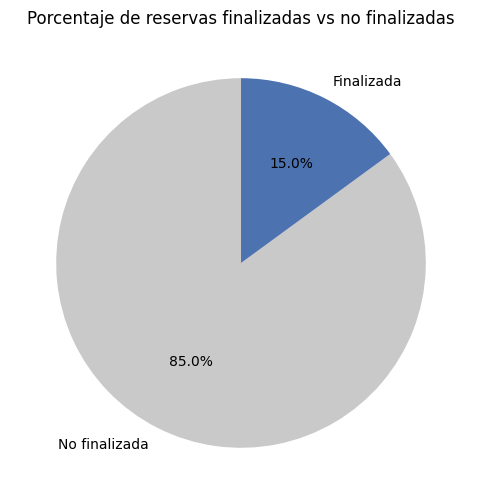

In [9]:
# Porcentaje de completadas vs no completadas

plt.figure(figsize=(8,6))
conteo_status = df['booking_complete'].value_counts().sort_index()
plt.pie(conteo_status, labels=['No finalizada', 'Finalizada'], autopct='%1.1f%%', startangle=90,
        colors=['#c9c9c9', '#4c72b0'])
plt.title("Porcentaje de reservas finalizadas vs no finalizadas")
plt.show()

Solo **1 de cada 7 reservas se completa**: la variable objetivo está desbalanceada. Por eso en todo el análisis se
comparan **tasas** (porcentajes) y no cantidades absolutas.

### 4.2 Construcción de columnas auxiliares


- `total_extras`: cantidad de adicionales pedidos (equipaje, asiento preferido y comidas), de 0 a 3.
- `cost_per_passenger`: costo de la reserva dividido por la cantidad de pasajeros. Reduce el efecto del tamaño del
  grupo al comparar precios (no lo elimina por completo: puede haber descuentos por grupo o diferencias por extras).

In [10]:
# Origen y destino: las 3 primeras y las 3 últimas letras de la ruta
df["origin"] = df["route"].str[:3]
df["destination"] = df["route"].str[3:]

# Día de vuelo como categoría ordenada de lunes a domingo, con su número (1 = lunes)
dias_orden = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
df["flight_day"] = pd.Categorical(df["flight_day"], categories=dias_orden, ordered=True)
df["flight_day_num"] = df["flight_day"].cat.codes + 1
df["is_weekend_flight"] = df["flight_day"].isin(["Sat", "Sun"]).astype(int)

# Momento del día según la hora del vuelo
df["flight_period"] = pd.cut(
    df["flight_hour"], bins=[-1, 5, 11, 17, 23],
    labels=["Madrugada (0-5)", "Mañana (6-11)", "Tarde (12-17)", "Noche (18-23)"],
)

# Grupos de anticipación de la compra (en días)
df["lead_group"] = pd.cut(
    df["purchase_lead"], bins=list(range(-1, 361, 30)) + [df["purchase_lead"].max()],
    labels=[f"Mes {m}" for m in range(1, 13)] + ["Más de 12 meses"],
)

# Adicionales pedidos por reserva (0 a 3) y costo por pasajero
df["total_extras"] = df[["wants_extra_baggage", "wants_preferred_seat", "wants_in_flight_meals"]].sum(axis=1)
df["has_extras"] = (df["total_extras"] > 0).astype(int)
df["cost_per_passenger"] = (df["booking_cost"] / df["num_passengers"]).round(2)

# Tipo de reserva según la cantidad de pasajeros
df["group_type"] = pd.cut(
    df["num_passengers"], bins=[0, 1, 2, df["num_passengers"].max()],
    labels=["Solo (1)", "Pareja (2)", "Grupo (3 o más)"],
)

df[["origin", "destination", "flight_day", "flight_day_num", "is_weekend_flight", "flight_period",
    "lead_group", "total_extras", "has_extras", "cost_per_passenger", "group_type"]].head()

,origin,destination,flight_day,flight_day_num,is_weekend_flight,flight_period,lead_group,total_extras,has_extras,cost_per_passenger,group_type
0,AKL,DEL,Sat,6,1,Mañana (6-11),Mes 9,1,1,493.65,Pareja (2)
1,AKL,DEL,Sat,6,1,Madrugada (0-5),Mes 4,0,0,406.91,Solo (1)
2,AKL,DEL,Wed,3,0,Tarde (12-17),Mes 9,2,1,437.76,Pareja (2)
3,AKL,DEL,Sat,6,1,Madrugada (0-5),Mes 4,1,1,508.69,Solo (1)
4,AKL,DEL,Wed,3,0,Tarde (12-17),Mes 3,2,1,548.82,Pareja (2)


In [11]:
# Cantidad de reservas en cada grupo, para verificar que ninguno quede vacío
for columna in ["flight_period", "lead_group", "group_type", "total_extras", "has_extras"]:
    print(df[columna].value_counts().sort_index().to_string(), "\n")

flight_period
Madrugada (0-5)    14619
Mañana (6-11)      18668
Tarde (12-17)      13749
Noche (18-23)       2964 

lead_group
Mes 1              16721
Mes 2              10812
Mes 3               6461
Mes 4               4034
Mes 5               2604
Mes 6               2094
Mes 7               1603
Mes 8               1454
Mes 9               1217
Mes 10               868
Mes 11               628
Mes 12               592
Más de 12 meses      912 

group_type
Solo (1)           31352
Pareja (2)         12804
Grupo (3 o más)     5844 

total_extras
0    10455
1    18216
2    12559
3     8770 

has_extras
0    10455
1    39545 



## Análisis exploratorio

En todo el análisis, **conversión** es el porcentaje de reservas completadas (`booking_complete = 1`) y "reserva no completada" es una reserva que el cliente no finalizó. El dataset no informa el motivo.

Para las hipótesis de rutas (H3) y países (H4) se arman dos tablas auxiliares con la cantidad de reservas y la conversión de cada ruta y de cada país.

In [12]:
# Tabla por ruta: cantidad de reservas y conversión (%)
por_ruta = (df.groupby('route', observed=True)['booking_complete']
              .agg(reservas='size', conversion='mean').reset_index()
              .sort_values('reservas', ascending=False).reset_index(drop=True))
por_ruta['conversion'] = por_ruta['conversion'] * 100

# Tabla por país de origen de la reserva: cantidad de reservas y conversión (%)
por_pais = (df.groupby('booking_origin', observed=True)['booking_complete']
              .agg(reservas='size', conversion='mean').reset_index()
              .sort_values('reservas', ascending=False).reset_index(drop=True))
por_pais['conversion'] = por_pais['conversion'] * 100

print(f"Rutas distintas: {len(por_ruta)}  |  Países de origen distintos: {len(por_pais)}")
por_ruta.head()

Rutas distintas: 799  |  Países de origen distintos: 103


,route,reservas,conversion
0,AKLKUL,2680,21.156716
1,PENTPE,924,43.398268
2,MELSGN,842,5.106888
3,ICNSIN,801,11.235955
4,DMKKIX,744,25.134409


### 4.4 Histogramas con KDE por hipótesis

- **H1:** anticipación de la compra, completadas vs no completadas (hasta el percentil 99).
- **H3:** conversión de cada ruta (combinaciones país-ruta con 20+ reservas) según el país de origen, para Malasia,
  China, Japón y Australia. La línea punteada es la mediana de cada país.
- **H4:** precio por pasajero relativo a la mediana de su ruta, Internet vs Mobile (solo rutas vendidas por ambos canales).
  Si Mobile fuera más barato, su curva estaría corrida a la izquierda del 1.

Se usa `common_norm=False` para que cada grupo se normalice por separado y se puedan comparar **formas** aunque los
grupos tengan tamaños muy distintos.


/tmp/ipykernel_781107/112277781.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  canales_por_ruta = df.groupby('route')['sales_channel'].nunique()
/tmp/ipykernel_781107/112277781.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  datos_h4.groupby('route')['cost_per_passenger'].transform('median'))


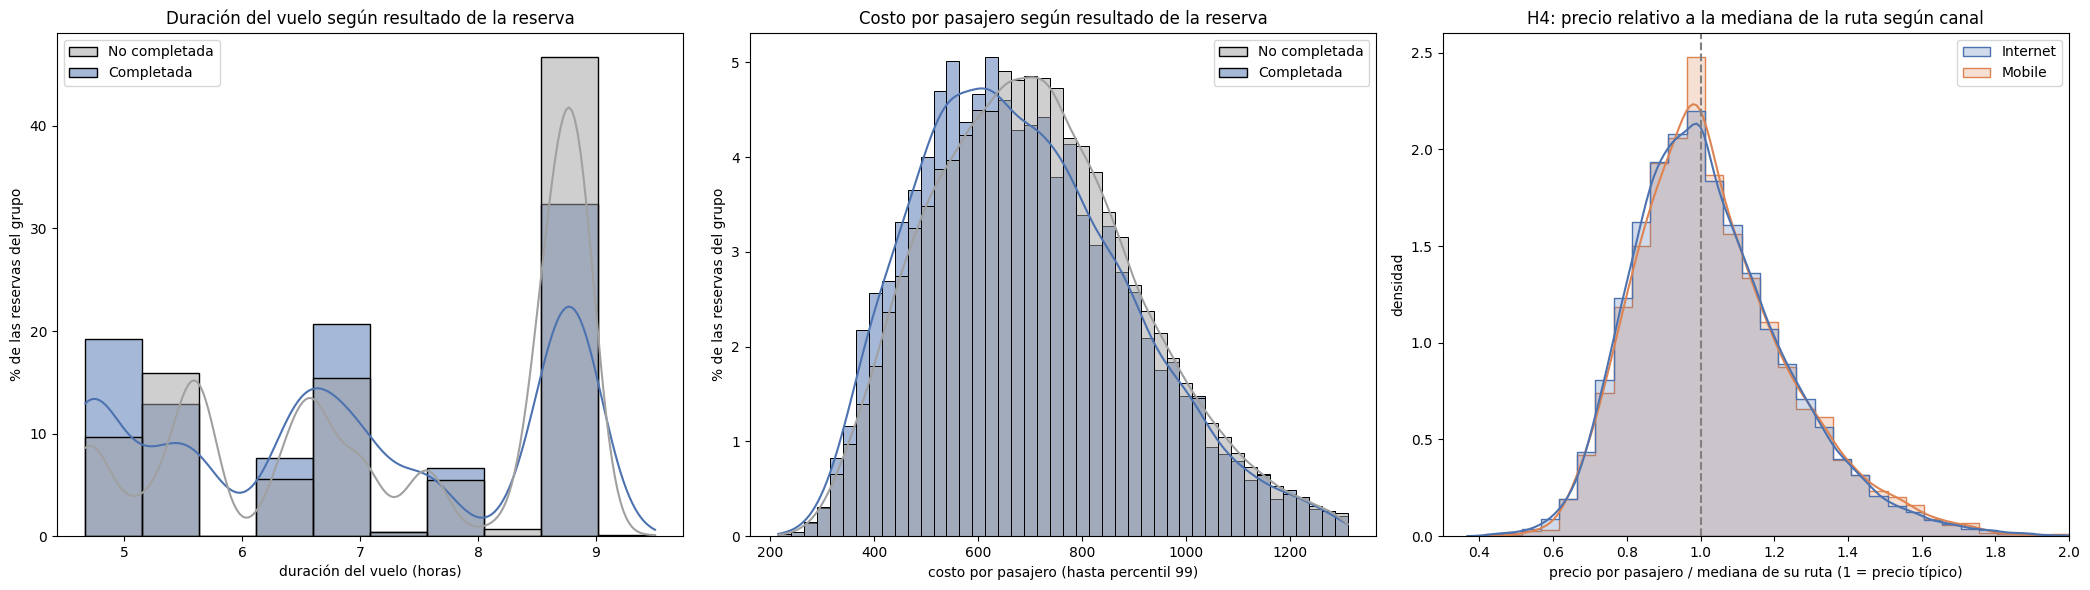

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
df['resultado'] = df['booking_complete'].map({0: 'No completada', 1: 'Completada'})

# 1) Duración del vuelo: ¿los vuelos largos se completan menos?
sns.histplot(data=df, x='flight_duration', hue='resultado', hue_order=['No completada', 'Completada'],
             stat='percent', common_norm=False, kde=True, binwidth=0.5,
             palette=['#a0a0a0', '#4c72b0'], ax=axes[0])
axes[0].set_title('Duración del vuelo según resultado de la reserva')
axes[0].set_xlabel('duración del vuelo (horas)')
axes[0].set_ylabel('% de las reservas del grupo')
axes[0].get_legend().set_title('')

# 2) Costo por pasajero: ¿las reservas que se completan son más baratas?
datos_costo = df[df['cost_per_passenger'] <= df['cost_per_passenger'].quantile(0.99)]
sns.histplot(data=datos_costo, x='cost_per_passenger', hue='resultado', hue_order=['No completada', 'Completada'],
             stat='percent', common_norm=False, kde=True, binwidth=25,
             palette=['#a0a0a0', '#4c72b0'], ax=axes[1])
axes[1].set_title('Costo por pasajero según resultado de la reserva')
axes[1].set_xlabel('costo por pasajero (hasta percentil 99)')
axes[1].set_ylabel('% de las reservas del grupo')
axes[1].get_legend().set_title('')


# H4: precio por pasajero relativo a la mediana de su ruta, por canal (solo rutas con ambos canales)
canales_por_ruta = df.groupby('route')['sales_channel'].nunique()
datos_h4 = df[df['route'].isin(canales_por_ruta[canales_por_ruta == 2].index)].copy()
datos_h4['precio_relativo'] = (datos_h4['cost_per_passenger'] /
                               datos_h4.groupby('route')['cost_per_passenger'].transform('median'))
sns.histplot(data=datos_h4, x='precio_relativo', hue='sales_channel', hue_order=['Internet', 'Mobile'],
             stat='density', common_norm=False, kde=True, binwidth=0.05, element='step',
             palette=['#4c72b0', '#dd8452'], ax=axes[2])
axes[2].axvline(1, color='gray', linestyle='--')
axes[2].set_xlim(0.3, 2.0)
axes[2].set_title('H4: precio relativo a la mediana de la ruta según canal')
axes[2].set_xlabel('precio por pasajero / mediana de su ruta (1 = precio típico)')
axes[2].set_ylabel('densidad')
axes[2].get_legend().set_title('')

plt.tight_layout()
plt.show()

- **Duración del vuelo:** las reservas no completadas se concentran en los vuelos largos (~9 h).
  Los vuelos de más de 8 horas convierten 10,7 % contra 18,5 % de los más cortos.
  Esto ayuda a explicar H3: Australia reserva sobre todo vuelos de ~9 h (mediana 8,6 h), Malasia de ~6,6 h.
- **Costo por pasajero:** las dos distribuciones tienen forma de campana con cola a la derecha,
  pero las completadas están levemente corridas hacia precios menores (mediana 670 vs 701).
  El precio influye en la conversión, aunque el efecto es chico.

### 4.5 Boxplots — detección de outliers
Un boxplot resume una variable con mínimo, Q1, mediana, Q3 y máximo. Es **outlier** todo valor fuera de
`[Q1 − 1,5·IQR ; Q3 + 1,5·IQR]` (criterio de Tukey, el mismo que dibuja el boxplot). Primero se cuantifican:
En H1 y H2 el eje se limita al percentil 99; los valores por encima siguen en el dataset.

In [14]:
def resumen_outliers(df, columnas):
    filas = []
    for col in columnas:
        serie = df[col].dropna()
        q1, q3 = serie.quantile([0.25, 0.75])
        iqr = q3 - q1
        lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_out = ((serie < lim_inf) | (serie > lim_sup)).sum()
        filas.append({"variable": col, "Q1": q1, "mediana": serie.median(), "Q3": q3,
                      "límite superior": lim_sup, "máximo": serie.max(),
                      "outliers": n_out, "% outliers": round(n_out / len(serie) * 100, 1)})
    return pd.DataFrame(filas).set_index("variable").round(1)

resumen_outliers(df, ["purchase_lead", "length_of_stay", "num_passengers", "booking_cost", "cost_per_passenger"])

,Q1,mediana,Q3,límite superior,máximo,outliers,% outliers
variable,,,,,,,
purchase_lead,21.0,51.0,115.0,256.0,867.0,3456,6.9
length_of_stay,5.0,17.0,28.0,62.5,778.0,3794,7.6
num_passengers,1.0,1.0,2.0,3.5,9.0,2903,5.8
booking_cost,667.2,883.2,1323.6,2308.3,7545.4,2954,5.9
cost_per_passenger,560.3,696.8,843.5,1268.3,2164.1,711,1.4


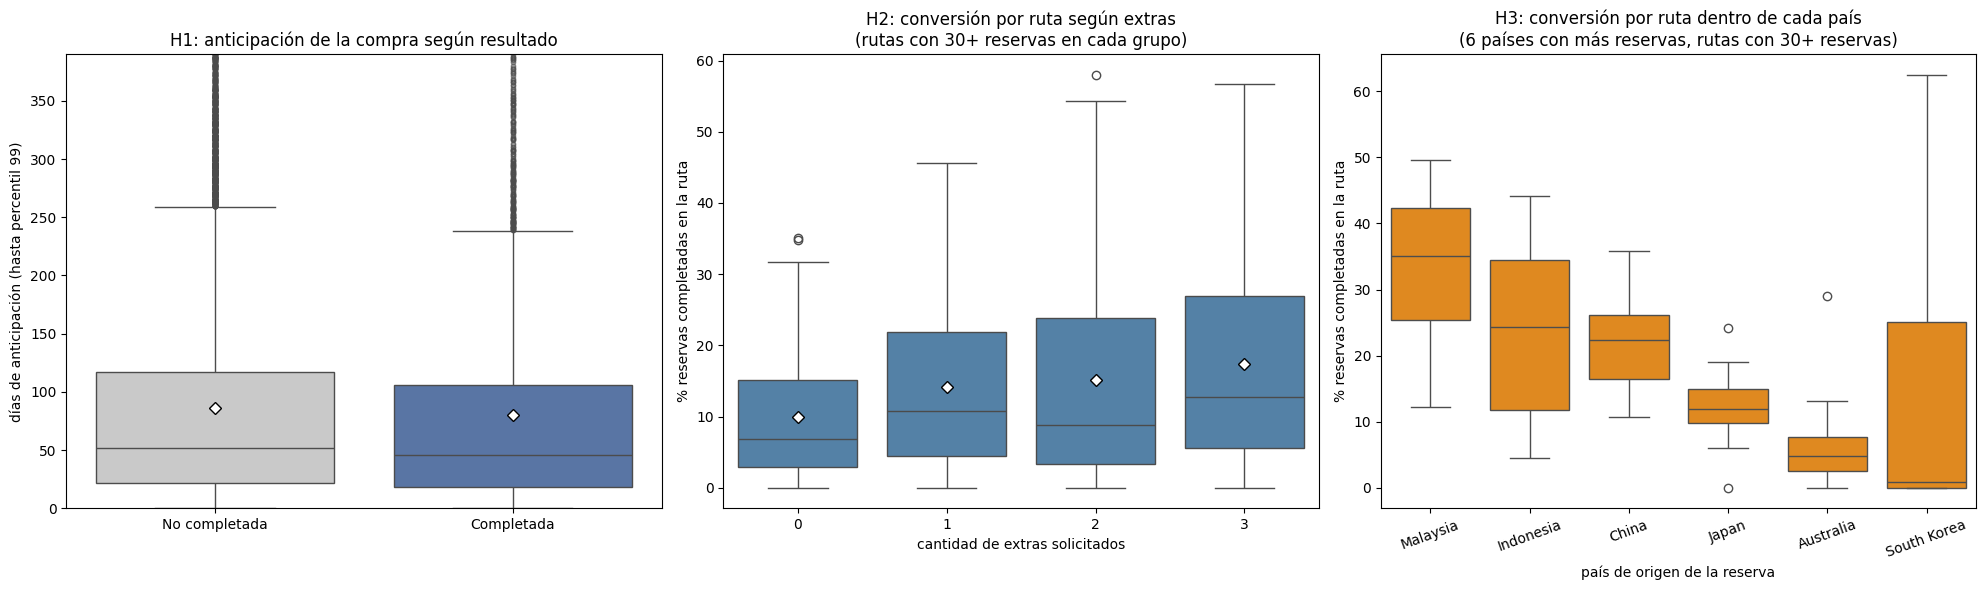

H2 - medianas por cantidad de extras: {0: 6.9, 1: 10.8, 2: 8.8, 3: 12.8}
H2 - medias por cantidad de extras: {0: 10.0, 1: 14.1, 2: 15.1, 3: 17.3}


In [15]:
MIN_RESERVAS = 30  # mínimo de reservas para que la conversión de una ruta sea confiable

# H2: conversión de cada ruta según la cantidad de extras
conv_ruta_extras = (df.groupby(["route", "total_extras"], observed=True)["booking_complete"]
                      .agg(reservas="size", conversion="mean").reset_index())
conv_ruta_extras = conv_ruta_extras[conv_ruta_extras["reservas"] >= MIN_RESERVAS]
conv_ruta_extras["conversion"] *= 100

# H3: conversión de cada ruta dentro de los 6 países con más reservas
top6_paises = df["booking_origin"].value_counts().head(6).index
conv_pais_ruta = (df[df["booking_origin"].isin(top6_paises)]
                    .groupby(["booking_origin", "route"], observed=True)["booking_complete"]
                    .agg(reservas="size", conversion="mean").reset_index())
conv_pais_ruta = conv_pais_ruta[conv_pais_ruta["reservas"] >= MIN_RESERVAS]
conv_pais_ruta["conversion"] *= 100
conv_pais_ruta["booking_origin"] = conv_pais_ruta["booking_origin"].astype(str)
orden_paises = conv_pais_ruta.groupby("booking_origin")["conversion"].median().sort_values(ascending=False).index

estilo_media = {"marker": "D", "markerfacecolor": "white", "markeredgecolor": "black"}
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.boxplot(data=df, x="booking_complete", y="purchase_lead", hue="booking_complete",
            palette=["#c9c9c9", "#4c72b0"], legend=False, showmeans=True, meanprops=estilo_media,
            flierprops={"markersize": 3, "alpha": 0.3}, ax=axes[0])
axes[0].set_ylim(0, df["purchase_lead"].quantile(0.99))
axes[0].set_xticks([0, 1], ["No completada", "Completada"])
axes[0].set_title("H1: anticipación de la compra según resultado")
axes[0].set_xlabel("")
axes[0].set_ylabel("días de anticipación (hasta percentil 99)")

sns.boxplot(data=conv_ruta_extras, x="total_extras", y="conversion", color="steelblue",
            showmeans=True, meanprops=estilo_media, ax=axes[1])
axes[1].set_title(f"H2: conversión por ruta según extras\n(rutas con {MIN_RESERVAS}+ reservas en cada grupo)")
axes[1].set_xlabel("cantidad de extras solicitados")
axes[1].set_ylabel("% reservas completadas en la ruta")

sns.boxplot(data=conv_pais_ruta, x="booking_origin", y="conversion", order=orden_paises,
            color="darkorange", ax=axes[2])
axes[2].set_title(f"H3: conversión por ruta dentro de cada país\n(6 países con más reservas, rutas con {MIN_RESERVAS}+ reservas)")
axes[2].set_xlabel("país de origen de la reserva")
axes[2].set_ylabel("% reservas completadas en la ruta")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

print("H2 - medianas por cantidad de extras:", conv_ruta_extras.groupby("total_extras")["conversion"].median().round(1).to_dict())
print("H2 - medias por cantidad de extras:", conv_ruta_extras.groupby("total_extras")["conversion"].mean().round(1).to_dict())

#### Interpretación y decisión sobre outliers
- **Outliers:** `purchase_lead` (6,9 %), `length_of_stay` (7,6 %), `num_passengers` (5,8 %) y `booking_cost` (5,9 %) tienen colas largas. Al pasar a `cost_per_passenger` los outliers bajan a 1,4 %: el costo "raro" se explicaba sobre todo por el tamaño del grupo.
- **Decisión: no se eliminan.** No son errores de carga (los valores imposibles se revisaron en la limpieza): son grupos grandes, compras muy anticipadas o estadías largas, poco frecuentes pero posibles. Incluso las 831 compras con más
de 365 días de anticipación se conservan; representan solo el 1,7 % y no cambian las conclusiones. En los gráficos se limita el eje al percentil 99 para que no compriman la escala.
- **H1:** las completadas tienen una mediana de anticipación algo menor, pero las cajas se superponen casi por completo.
- **H2:** la conversión **media** por ruta sube con los extras (10,1 % → 14,2 % → 15,1 % → 17,4 %); la mediana no es estrictamente creciente (con 2 extras es menor que con 1)porque cada caja incluye rutas distintas y la dispersión es alta.
- **H3:** las cajas de Malasia y Australia ni se tocan: el país pesa más que la ruta.

### 4.6 Scatterplots

- **H3:** cada punto es un **país** (con 100+ reservas). Eje x: cantidad de reservas (escala log); eje y: conversión. El tamaño del punto es la cantidad de reservas y el color va de rojo (baja conversión) a verde (alta). La línea punteada es la conversión global. Si la conversión no dependiera del país, todos los puntos estarían cerca de esa línea.
- **H4:** cada punto es una **ruta** vendida por ambos canales (10+ reservas en cada uno).
Eje x: precio mediano por pasajero en Internet; eje y: el mismo precio en Mobile.
La diagonal es "mismo precio": **debajo de la diagonal Mobile es más barato** y arriba,más caro.
Se usa el costo **por pasajero** para que no influya el tamaño del grupo.

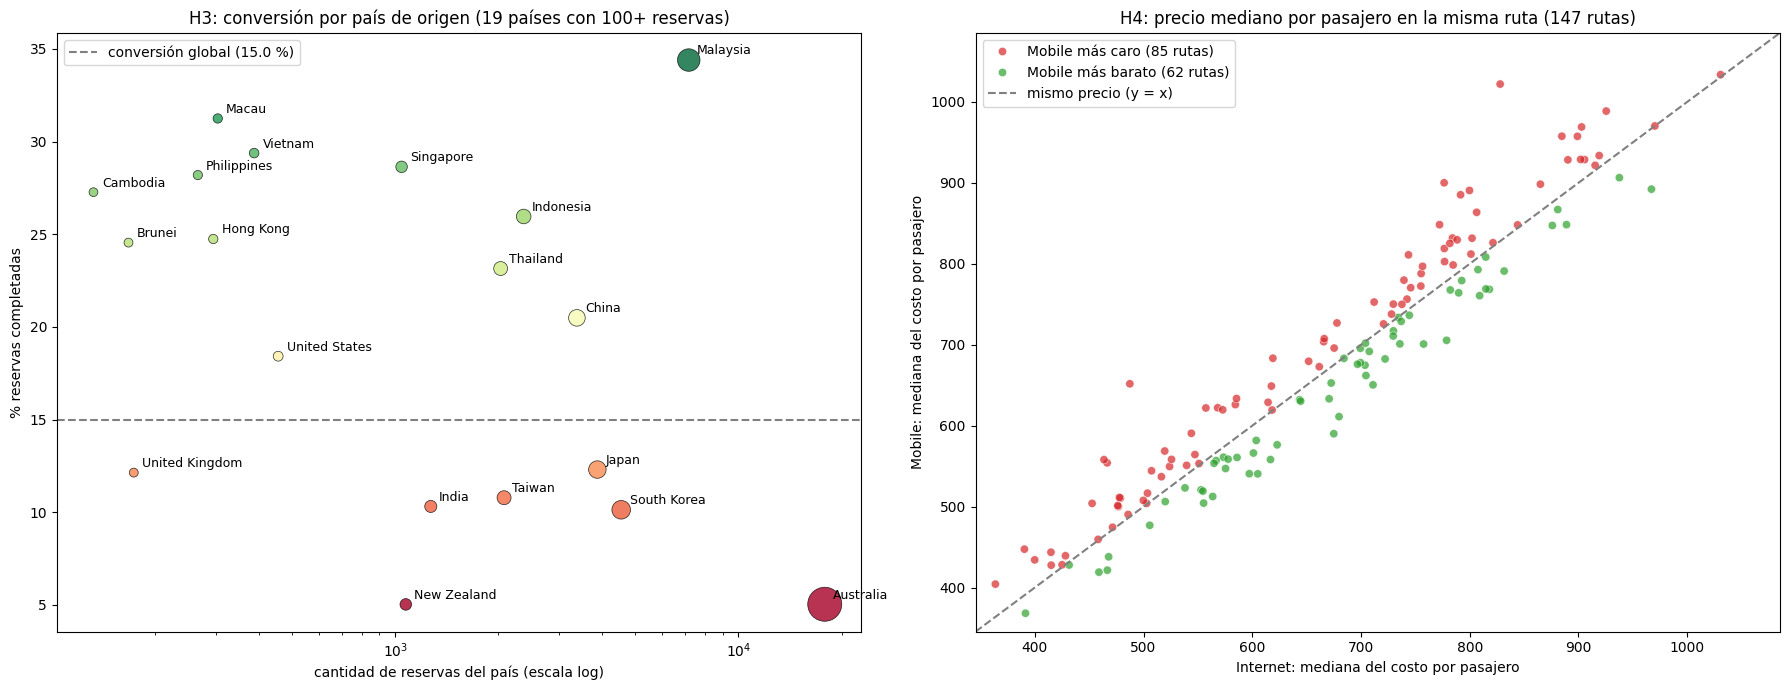

H4: rutas comparables 147 | Mobile más barato en 62 | más caro en 85
H4: diferencia mediana Mobile vs Internet: +0.7 %
H3: correlación de Spearman volumen vs conversión: -0.34


In [16]:
# H3: una fila por país con su cantidad de reservas y su conversión (%)
por_pais = (df.groupby("booking_origin", observed=True)["booking_complete"]
              .agg(reservas="size", conversion="mean").reset_index())
por_pais["conversion"] *= 100
conversion_global = df['booking_complete'].mean() * 100  # referencia para las líneas punteadas
paises_100 = por_pais[por_pais["reservas"] >= 100]  # con pocas reservas la conversión es inestable

# H4: mediana del costo por pasajero de cada canal en cada ruta (10+ reservas por canal)
mediana_canal = (df.groupby(["route", "sales_channel"], observed=True)["cost_per_passenger"]
                   .agg(["size", "median"]).reset_index())
mediana_canal = (mediana_canal[mediana_canal["size"] >= 10]
                   .pivot(index="route", columns="sales_channel", values="median").dropna())
mas_barato = mediana_canal["Mobile"] < mediana_canal["Internet"]
mediana_canal["comparacion"] = np.where(mas_barato, f"Mobile más barato ({mas_barato.sum()} rutas)",
                                        f"Mobile más caro ({(~mas_barato).sum()} rutas)")
mediana_canal["dif_mobile_%"] = (mediana_canal["Mobile"] / mediana_canal["Internet"] - 1) * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.scatterplot(data=paises_100, x="reservas", y="conversion", size="reservas", sizes=(40, 600),
                hue="conversion", palette="RdYlGn", edgecolor="black", alpha=0.8, legend=False, ax=axes[0])
axes[0].set_xscale("log")
axes[0].axhline(conversion_global, color="gray", linestyle="--", label=f"conversión global ({conversion_global:.1f} %)")
for _, fila in paises_100.iterrows():
    axes[0].annotate(fila["booking_origin"], (fila["reservas"], fila["conversion"]),
                     xytext=(6, 4), textcoords="offset points", fontsize=9)
axes[0].set_title(f"H3: conversión por país de origen ({len(paises_100)} países con 100+ reservas)")
axes[0].set_xlabel("cantidad de reservas del país (escala log)")
axes[0].set_ylabel("% reservas completadas")
axes[0].legend(loc="upper left")

sns.scatterplot(data=mediana_canal, x="Internet", y="Mobile", hue="comparacion",
                palette=["#d62728", "#2ca02c"], hue_order=sorted(mediana_canal["comparacion"].unique(), reverse=True),
                alpha=0.7, ax=axes[1])
limites = [mediana_canal[["Internet", "Mobile"]].min().min() * 0.95,
           mediana_canal[["Internet", "Mobile"]].max().max() * 1.05]
axes[1].plot(limites, limites, color="gray", linestyle="--", label="mismo precio (y = x)")
axes[1].set_xlim(limites)
axes[1].set_ylim(limites)
axes[1].set_title(f"H4: precio mediano por pasajero en la misma ruta ({len(mediana_canal)} rutas)")
axes[1].set_xlabel("Internet: mediana del costo por pasajero")
axes[1].set_ylabel("Mobile: mediana del costo por pasajero")
axes[1].legend(title="", loc="upper left")

plt.tight_layout()
plt.show()

print(f"H4: rutas comparables {len(mediana_canal)} | Mobile más barato en {mas_barato.sum()} | más caro en {(~mas_barato).sum()}")
print(f"H4: diferencia mediana Mobile vs Internet: {mediana_canal['dif_mobile_%'].median():+.1f} %")
print(f"H3: correlación de Spearman volumen vs conversión: {paises_100['reservas'].corr(paises_100['conversion'], method='spearman'):.2f}")

#### Interpretación

- **H3 — se cumple con claridad.** La conversión va de **5 %** (Australia, Nueva Zelanda) a **34,5 %** (Malasia),
  casi 7 veces más. Los puntos se separan en dos grupos: los países del sudeste asiático (Malasia, Macao,
  Vietnam, Singapur, Indonesia) por encima de la media, y Australia, Nueva Zelanda, Corea, Japón, Taiwán e
  India por debajo. Dato clave: **Australia es el mercado con más reservas (≈17.800) y el que peor convierte**.
  La correlación entre volumen y conversión es negativa (−0,36): tener más reservas no implica convertir mejor.
- **H4 — se rechaza.** Los puntos siguen casi exactamente la diagonal (correlación 0,96): en una misma ruta
  ambos canales cobran precios muy parecidos. Y cuando difieren, Mobile es **más caro** en 88 de 144 rutas (61 %).
  No hay evidencia de que Mobile sea más barato.

### 4.7 Visualizaciones adicionales


#### H1 — Conversión según anticipación (líneas + barras)
Las barras grises muestran **cuántas reservas** hay en cada tramo de anticipación y la línea azul,
**qué porcentaje se completó**. La línea punteada es la conversión global.

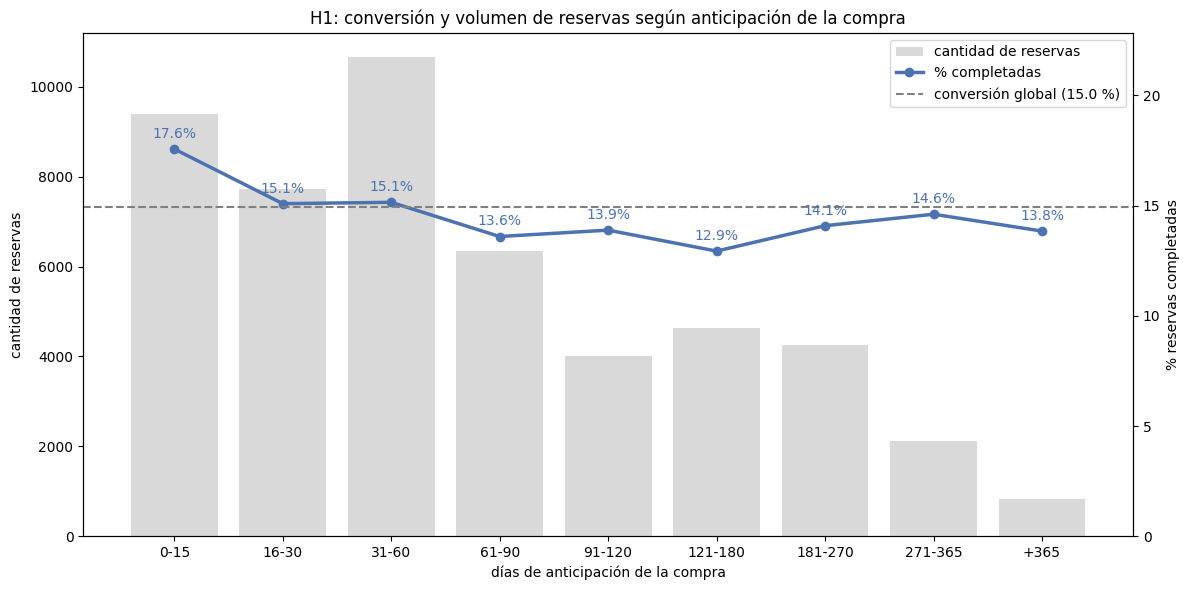

In [17]:
conversion_global = df['booking_complete'].mean() * 100

# Tramos de anticipación más finos al principio, donde se concentran las reservas
grupos = [-1, 15, 30, 60, 90, 120, 180, 270, 365, df['purchase_lead'].max()]
etiquetas = ['0-15', '16-30', '31-60', '61-90', '91-120', '121-180', '181-270', '271-365', '+365']
df['lead_tramo'] = pd.cut(df['purchase_lead'], bins=grupos, labels=etiquetas)
por_tramo = df.groupby('lead_tramo', observed=True)['booking_complete'].agg(reservas='size', conversion='mean')
por_tramo['conversion'] *= 100

fig, ax1 = plt.subplots(figsize=(12, 6))

# Eje izquierdo: volumen de reservas (barras)
ax1.bar(por_tramo.index, por_tramo['reservas'], color='#d9d9d9', label='cantidad de reservas')
ax1.set_xlabel('días de anticipación de la compra')
ax1.set_ylabel('cantidad de reservas')

# Eje derecho: conversión (línea)
ax2 = ax1.twinx()
ax2.plot(por_tramo.index, por_tramo['conversion'], marker='o', color='#4c72b0', linewidth=2.5, label='% completadas')
ax2.axhline(conversion_global, color='gray', linestyle='--', label=f'conversión global ({conversion_global:.1f} %)')
for x, y in zip(por_tramo.index, por_tramo['conversion']):
    ax2.annotate(f'{y:.1f}%', (x, y), xytext=(0, 8), textcoords='offset points', ha='center', color='#4c72b0')
ax2.set_ylabel('% reservas completadas')
ax2.set_ylim(0, por_tramo['conversion'].max() * 1.3)

# Una sola leyenda para los dos ejes
lineas = ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
textos = ax1.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
ax1.legend(lineas, textos, loc='upper right')
plt.title('H1: conversión y volumen de reservas según anticipación de la compra')
plt.tight_layout()
plt.show()

#### H2 — Conversión según extras (barras)
Izquierda: conversión según la **cantidad** de extras. Derecha: conversión de quienes pidieron o no
**cada extra** por separado, para ver cuál está más asociado a completar la reserva.

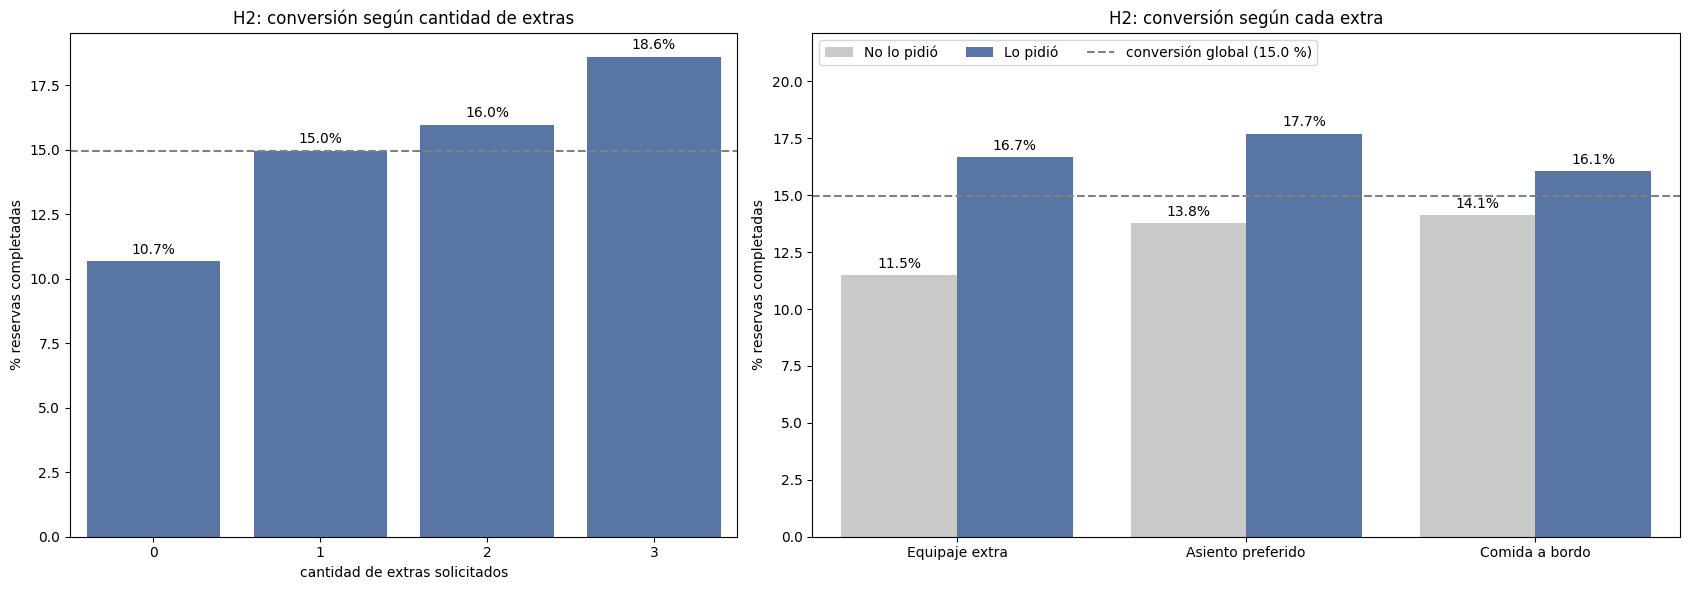

In [18]:
extras = {'wants_extra_baggage': 'Equipaje extra', 'wants_preferred_seat': 'Asiento preferido',
          'wants_in_flight_meals': 'Comida a bordo'}

# Conversión de quienes pidieron / no pidieron cada extra
filas = []
for col, nombre in extras.items():
    for valor, texto in [(0, 'No lo pidió'), (1, 'Lo pidió')]:
        filas.append({'extra': nombre, 'solicitado': texto,
                      'conversion': df.loc[df[col] == valor, 'booking_complete'].mean() * 100})
conv_por_extra = pd.DataFrame(filas)
conv_por_cantidad = df.groupby('total_extras')['booking_complete'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(17, 6), gridspec_kw={'width_ratios': [1, 1.3]})

sns.barplot(x=conv_por_cantidad.index, y=conv_por_cantidad.values, color='#4c72b0', ax=axes[0])
for i, v in enumerate(conv_por_cantidad.values):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center')
axes[0].axhline(conversion_global, color='gray', linestyle='--')
axes[0].set_title('H2: conversión según cantidad de extras')
axes[0].set_xlabel('cantidad de extras solicitados')
axes[0].set_ylabel('% reservas completadas')

sns.barplot(data=conv_por_extra, x='extra', y='conversion', hue='solicitado',
            palette=['#c9c9c9', '#4c72b0'], ax=axes[1])
for barras in axes[1].containers:
    axes[1].bar_label(barras, fmt='%.1f%%', padding=3)
axes[1].axhline(conversion_global, color='gray', linestyle='--', label=f'conversión global ({conversion_global:.1f} %)')
axes[1].set_title('H2: conversión según cada extra')
axes[1].set_xlabel('')
axes[1].set_ylabel('% reservas completadas')
axes[1].set_ylim(0, conv_por_extra['conversion'].max() * 1.25)
axes[1].legend(title='', loc='upper left', ncol=3)

plt.tight_layout()
plt.show()

#### H3 — Resultado de las reservas por país (barras apiladas al 100 %)
Cada barra es un país (los 10 con más reservas) y suma 100 %: la parte azul son las completadas.
A la derecha, la cantidad de reservas del país, para no confundir peso con conversión.

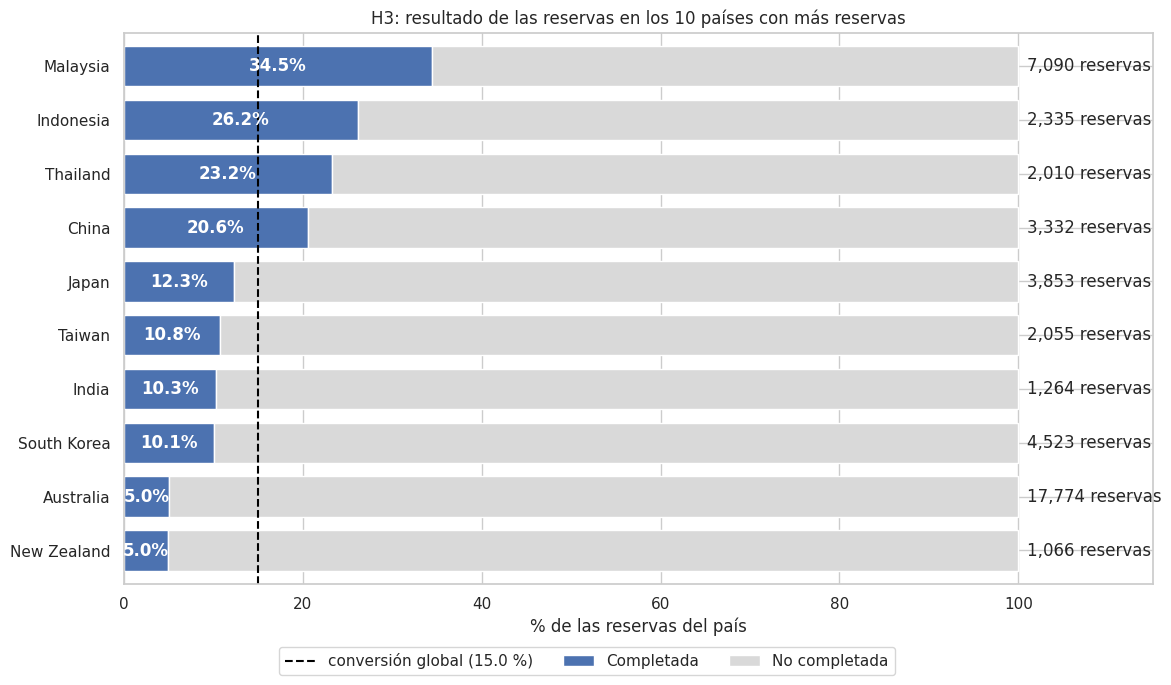

In [ ]:
top10 = df['booking_origin'].value_counts().head(10).index

# % de completadas y no completadas dentro de cada país
resultado = (pd.crosstab(df.loc[df['booking_origin'].isin(top10), 'booking_origin'],
                         df['booking_complete'], normalize='index') * 100)
resultado.columns = ['No completada', 'Completada']
resultado = resultado[['Completada', 'No completada']].sort_values('Completada')
reservas_pais = df['booking_origin'].value_counts()

ax = resultado.plot(kind='barh', stacked=True, color=['#4c72b0', '#d9d9d9'], figsize=(12, 7), width=0.75)
for i, pais in enumerate(resultado.index):
    ax.text(resultado.loc[pais, 'Completada'] / 2, i, f"{resultado.loc[pais, 'Completada']:.1f}%",
            va='center', ha='center', color='white', fontweight='bold')
    ax.text(101, i, f'{reservas_pais[pais]:,} reservas', va='center')
ax.axvline(conversion_global, color='black', linestyle='--', label=f'conversión global ({conversion_global:.1f} %)')
ax.set_xlim(0, 115)
ax.set_title('H3: resultado de las reservas en los 10 países con más reservas')
ax.set_xlabel('% de las reservas del país')
ax.set_ylabel('')
ax.legend(loc='upper center', bbox_to_anchor=(0.45, -0.1), ncol=3)
plt.tight_layout()
plt.show()

#### Interpretación
- **H1 — se cumple, pero el efecto es chico.** La conversión cae de **17,5 %** (compras con 0-15 días de
  anticipación) a ~**13-14 %** a partir de los 60 días, y después se estabiliza: no sigue bajando.
  Además, el 55 % de las reservas se hacen con menos de 60 días de anticipación.
- **H2 — se cumple.** La conversión sube de forma constante con cada extra: **10,7 % → 15 % → 16 % → 18,5 %**.
  El extra más asociado es el **equipaje** (16,7 % vs 11,5 %, +5,2 puntos), seguido del asiento preferido (+3,9).
  La comida a bordo es la que menos diferencia marca (+1,8).
- **H3 — se cumple con claridad.** Malasia convierte **34,5 %** y Australia **5 %**. Australia concentra
  ≈17.800 reservas (36 % del total) pero solo 1 de cada 20 se completa: es el mercado con más volumen
  y peor conversión.

/tmp/ipykernel_1233550/638975720.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  canales_por_ruta = df.groupby('route')['sales_channel'].nunique()


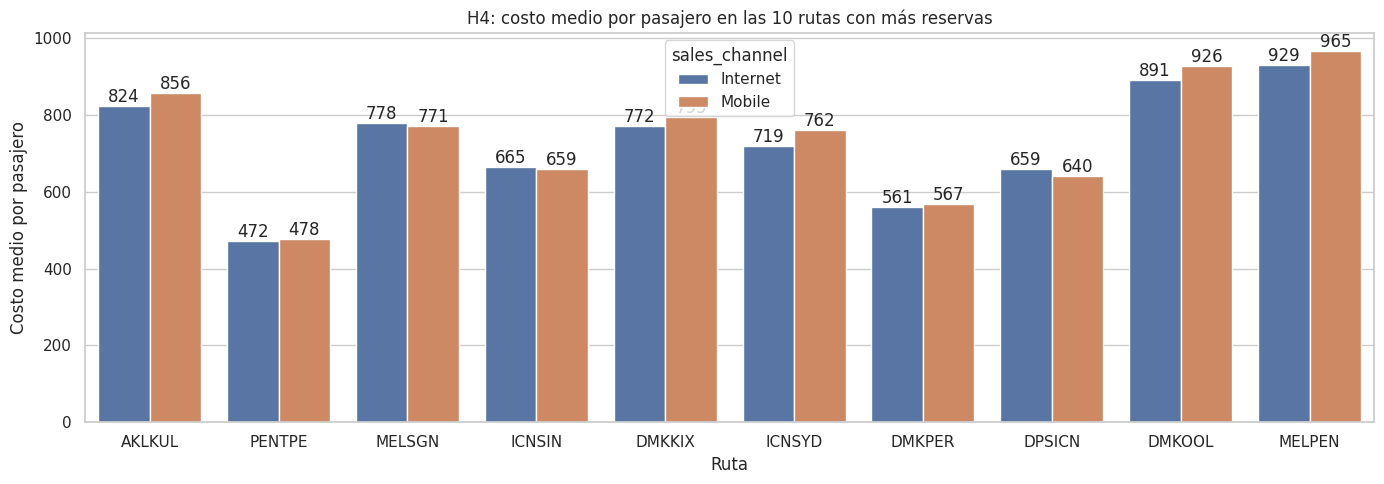

In [ ]:
# H4: ante la misma ruta, ¿es más barato Mobile que Internet? (10 rutas con más reservas que tienen ambos canales)
canales_por_ruta = df.groupby('route')['sales_channel'].nunique()
rutas_con_ambos = canales_por_ruta[canales_por_ruta == 2].index

top10_rutas = df[df['route'].isin(rutas_con_ambos)]['route'].value_counts().head(10).index
top10 = df[df['route'].isin(top10_rutas)]

plt.figure(figsize=(14, 5))
ax = sns.barplot(data=top10, x='route', y='cost_per_passenger', hue='sales_channel',
                 order=top10_rutas, errorbar=None)
ax.set_title('H4: costo medio por pasajero en las 10 rutas con más reservas')
ax.set_xlabel('Ruta')
ax.set_ylabel('Costo medio por pasajero')
for contenedor in ax.containers:
    ax.bar_label(contenedor, fmt='%.0f')
plt.tight_layout()
plt.show()

### 4.8 Correlaciones
Matriz de correlación entre las variables numéricas y la variable objetivo `booking_complete`.

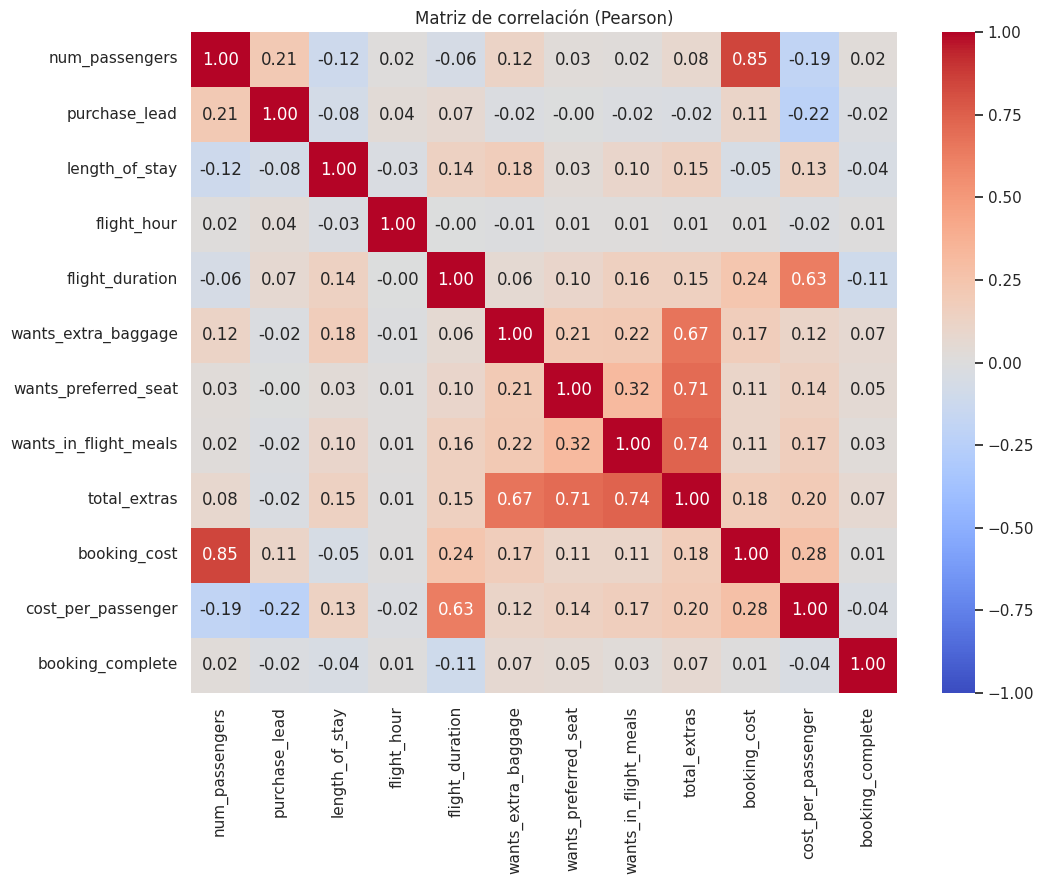

flight_duration         -0.106
length_of_stay          -0.042
cost_per_passenger      -0.038
purchase_lead           -0.022
booking_cost             0.006
flight_hour              0.007
num_passengers           0.024
wants_in_flight_meals    0.026
wants_preferred_seat     0.049
total_extras             0.067
wants_extra_baggage      0.068


In [ ]:
columnas_corr = ["num_passengers", "purchase_lead", "length_of_stay", "flight_hour", "flight_duration",
                 "wants_extra_baggage", "wants_preferred_seat", "wants_in_flight_meals", "total_extras",
                 "booking_cost", "cost_per_passenger", "booking_complete"]
matriz = df[columnas_corr].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(matriz, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Matriz de correlación (Pearson)")
plt.tight_layout()
plt.show()

print(matriz["booking_complete"].drop("booking_complete").sort_values().round(3).to_string())

## 5. Conclusiones

| Hipótesis | Resultado | Evidencia principal |
|---|---|---|
| **H1** — más anticipación, más reservas no completadas | ✅ **Se cumple parcialmente** (efecto chico) | Conversión 17,5 % con 0-15 días vs 13,0-14,5 % desde los 60 días; medianas 46 vs 51 días; chi² significativo |
| **H2** — más extras, más conversión | ✅ **Se cumple** | 10,7 % → 15,0 % → 16,0 % → 18,5 % con 0 a 3 extras; el equipaje es el extra más asociado |
| **H3** — la conversión depende del país | ✅ **Se cumple con claridad** | De 5,0 % (Australia) a 34,5 % (Malasia); la diferencia se repite ruta por ruta |
| **H4** — misma ruta, Mobile más barato | ❌ **Se rechaza** | Diferencia mediana +1,3 %; Mobile más caro en 88 de 144 rutas; Wilcoxon p = 0,99 |


- `length_of_stay` tiene un hueco sin datos entre 7 y 16 días, y 80 reservas no tienen país de origen.
- Las relaciones encontradas son asociaciones: el país, la ruta y los extras están mezclados entre sí y no se
  controlaron con un modelo multivariado.
